In [8]:
import numpy as np
from numpy import linalg as LA
import pandas as pd
import operator as op
import ipynbname
import math
import time
from Functions.Utils import *
from Functions.RLS import *
from Functions.Utils_RTLO import *
from Functions.RTLO_R1 import *
from Functions.Graphs import *
#from Functions.TEDA import *
from Functions.TEDA_R1 import *
from Functions.TedaGraphs import *
import optuna
from optuna.visualization import plot_parallel_coordinate
from optuna.visualization import plot_pareto_front
from optuna.importance import get_param_importances
from optuna.samplers import RandomSampler
import os
import re
import sys
import matplotlib.cm as cm
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import matplotlib as mpl
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import random
import pickle
FileName = ipynbname.name()
K=0

df = pd.read_csv(r'Dataset\Dataset_1_NCA_battery_SoH\CY25-05_1-#01.csv')
sig = df['soh'].values

Mp = [1.54, 3, 0, False]
Mp2 =[5, 25, 0.01, 1e-06, 1e-10, 1e-07, 22]

m, nRS, st, drop= Mp
nHI, nR, N1, N2, N3,D, tau = Mp2


In [9]:
X, Y = PrepareDataPast(sig,nHI,nHI)
teda=AutoCloud(m=2,nS=len(X[0]), nI=1, nR=1, nO=1, ηS=[1,1,1],
                            tau=1, decay=1, eol=0.8, fator=1) 
teda.add_rulR2(n=-(st+nRS)+len(X))
for j,_ in enumerate(X):
    x = X[j]
    teda.run(X=x,MergeGrnls=True,MergeOffGrnls=True,FitOffGrnls=True,OfflineRun=True)

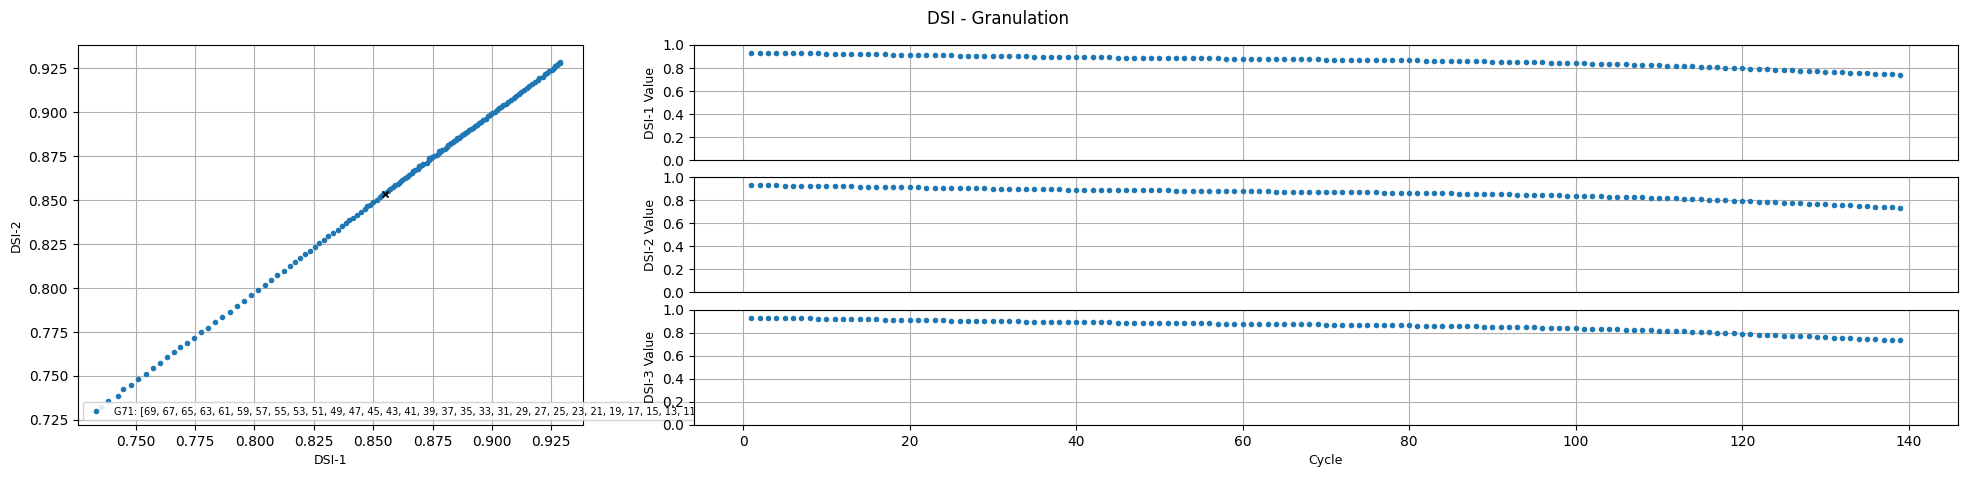

In [10]:
plot_DSI2(teda,ftrs=3,title='DSI - Granulation',ncol=2,w=20,h=5)


In [12]:

for i in range(1):
    mapeInit,check = None, False
    xS,yS,zS = X, X, Y
    if i==0: 
        teda=AutoCloud(m=m, nS=len(xS[0]), nI=len(yS[0]), nR=nR, nO=len(yS[0]), 
                            ηS= [N1, N2, N3], tau=tau, decay=D,
                            eol=0.8, fator=1,st=st+nRS-1) 
    elif i>0: teda.reset_rul()
    teda.win_all = True
    teda.add_rulR2(n=-(nRS)+len(X))
    for j,_ in enumerate(xS):
        x,y,z= xS[j],yS[j],zS[j]
        teda.run(X=x,MergeGrnls=True,MergeOffGrnls=True,FitOffGrnls=True,OfflineRun=True)

        teda.adapt(y,z)

        teda.RUL_single(y)

        if i ==0:
            if np.any(1 != teda.cloud_activation2[-1]) and not check:
                mapeInit=j
                check = True
                DamagedGrnl = (teda.cloud_activation2[-1])
        elif i>0 and not check:
            if DamagedGrnl in teda.cloud_activation3[-1]:
                mapeInit = j + 0
                check = True

    mape2 = teda.MAPE(start=mapeInit,rulR=teda.rulR2)
    check = False
    print(mape2,mapeInit)
    plot_2series(x1=teda.cycleP,x2=teda.cycleP,y1=teda.rulR2,y2=teda.rulP, title='brng',s1='True',s2='Pred')
#plot_DSI2(teda,ftrs=3,title='DSI - Granulation',ncol=2)


0.9597117135944997 5


In [12]:
m, nRS, st, drop= Mp
nHI, nR, N1, N2, N3,D, tau = Mp2
init = (st+nRS)
len_=0
for i,brng in enumerate(brngs[:1]):
    mapeInit,check = None, False
    df_RS = (pd.read_csv(os.path.join(dir_rs,brng)).abs()).iloc[:,:-1]
    df_HI = (pd.read_csv(os.path.join(dir_hi,brng)).abs()).iloc[:,-1:]
    if drop: df_RS = df_RS.drop(columns='Y')
    RS = process_RS(df_RS,nRS)
    HI = process_HI(df_HI,nHI=nHI,init=init)
    xS,yS,zS = RS[st:-2], HI[:-1], HI[1:]
    if i==0: 
        teda=AutoCloud(m=m, nS=len(xS[0]), nI=len(yS[0]), nR=nR, nO=len(yS[0]), 
                            ηS=[N1, N2, N3], tau=tau, decay=D,
                            eol=0.2, fator=1,st=st+nRS-1) 
    elif i>0: teda.reset_rul()
    teda.win_all = True
    teda.add_rulR2(n=-(st+nRS)+len(df_RS))
    for j,_ in enumerate(xS):
        x= xS[j]
        y,z = yS[j],zS[j]

        if i <= 1: teda.run(X=x,MergeGrnls=True,MergeOffGrnls=True,FitOffGrnls=True,OfflineRun=True)
        else: teda.run(x,MergeGrnls=True,MergeOffGrnls=True,FitOffGrnls=True, OfflineRun=True)
        
        teda.adapt(y,z)
        teda.RUL_single(y)

        if i ==0:
            if np.any(1 != teda.cloud_activation2[-1]) and not check:
                mapeInit=j
                check = True
                DamagedGrnl = (teda.cloud_activation2[-1])
        elif i>0 and not check:
            if DamagedGrnl in teda.cloud_activation3[-1]:
                mapeInit = j + 0
                check = True

    mape2 = teda.MAPE(start=mapeInit,rulR=teda.rulR2)
    check = False
    print(mape2,mapeInit)
    plot_2series(x1=teda.cycleP,x2=teda.cycleP,y1=teda.rulR2,y2=teda.rulP, title=brng,s1='True',s2='Pred')
#plot_DSI2(teda,ftrs=3,title='DSI - Granulation',ncol=2)


0.7222563277018518 4
